# 08 - Hardware Buffers: DDR4 and MR

**Objective:** Learn how to use the DDR4 buffer (for long-duration captures) and the MR (Multi-Rate) buffer (for fast, tProc-accessible captures). Understand when to use each buffer type.

## 1. Setup

In [ ]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging

from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Connect to the board (adjust the path to your firmware)
BITSTREAM_PATH = '/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

## 2. Understanding Hardware Buffers

QICK provides two types of hardware buffers for capturing readout data:

| Buffer | Size | Access | Best for |
| :--- | :--- | :--- | :--- |
| **DDR4 Buffer** | Very large (up to ~1 second of data) | Read from Python after experiment | Long acquisitions, many repetitions |
| **MR Buffer** | Small (typically 8192 samples) | Read by tProc during experiment | Fast feedback, real-time decision making |

**Key concepts:**
- Both buffers capture **decimated** IQ data (after downconversion and filtering)
- You can enable one or both in the same experiment
- Data is written continuously; you must manage buffer overflow

## 3. Capturing Data to DDR4 Buffer

The DDR4 buffer is ideal for capturing long sequences or many repetitions. It stores data in the board's DDR4 memory, which can hold millions of samples.

  0%|          | 0/60 [00:00<?, ?it/s]

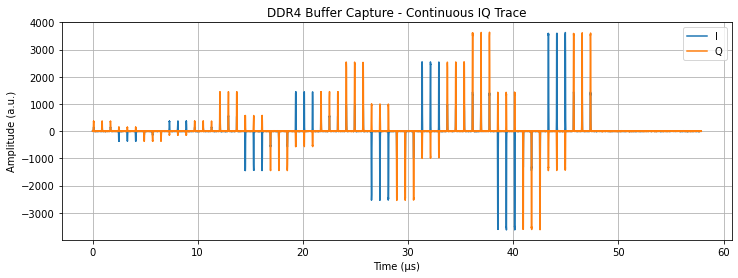

Captured 32000 IQ samples from DDR4 buffer
Total duration: 57.87 µs


In [3]:
class DDR4Program(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define loops (outer = gain sweep, inner = phase sweep)
        self.add_loop("gain_loop", self.cfg["steps_gain"])
        self.add_loop("phase_loop", self.cfg["steps_phase"])

        # Define a Gaussian envelope
        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name="ramp", 
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        
        # Define a flat-top pulse with sweeps
        self.add_pulse(ch=gen_ch, name="swept_pulse", 
                       style="flat_top", envelope="ramp",
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=QickSweep1D("phase_loop", 0, 360),
                       gain=QickSweep1D("gain_loop", 0.1, 1.0))

        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="swept_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'],
                    ddr4=True, mr=False)  # Enable DDR4, disable MR

# Configuration for DDR4 capture
config_ddr4 = {
    'steps_gain': 4,
    'steps_phase': 5,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'ro_len': 0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2
}

# Arm the DDR4 buffer before running
# Each transfer (burst) is 256 decimated samples
n_transfers = 10000  # Total samples = 256 * n_transfers
soc.arm_ddr4(ch=RO_CH, nt=n_transfers)

# Run the program
prog = DDR4Program(soccfg, reps=3, final_delay=1.0, cfg=config_ddr4, reps_innermost=True)
iq_list = prog.acquire(soc, rounds=1, progress=True)

# Read data from DDR4 buffer
# Request more samples than we expect to ensure we get everything
iq_ddr4 = soc.get_ddr4(250)
t_ddr4 = prog.get_time_axis_ddr4(RO_CH, iq_ddr4)

plt.figure(figsize=(12, 4))
plt.plot(t_ddr4, iq_ddr4[:,0], label='I')
plt.plot(t_ddr4, iq_ddr4[:,1], label='Q')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('DDR4 Buffer Capture - Continuous IQ Trace')
plt.legend()
plt.grid(True)
plt.show()

print(f"Captured {len(iq_ddr4)} IQ samples from DDR4 buffer")
print(f"Total duration: {t_ddr4[-1]:.2f} µs")

**Explanation:**
- `arm_ddr4(ch, nt)` prepares the buffer. `nt` is the number of transfers (each transfer = 256 decimated samples)
- Setting `ddr4=True` in `trigger()` enables DDR4 capture
- `get_ddr4(n)` reads data from the buffer. Request extra samples to ensure you get everything
- The data is continuous across all shots and sweep steps, showing the loop order

## 4. Capturing Data to MR Buffer

The MR (Multi-Rate) buffer is smaller but accessible to the tProc, making it useful for feedback and fast processing.

  0%|          | 0/1 [00:00<?, ?it/s]

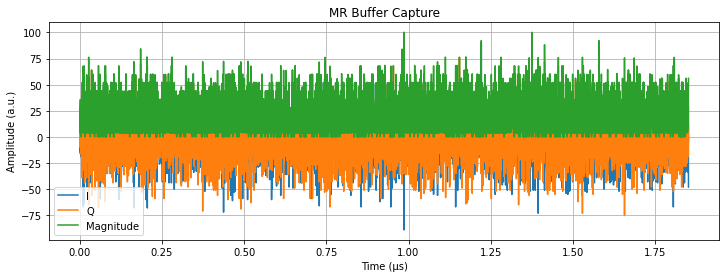

Captured 8192 IQ samples from MR buffer
MR-related config keys: ['buf_maxlen', 'avgbuf_revision', 'avgbuf_type', 'avgbuf_version', 'avgbuf_fullpath']
  buf_maxlen: 16384
  avgbuf_revision: 4
  avgbuf_type: axis_avg_buffer
  avgbuf_version: 1.2
  avgbuf_fullpath: axis_avg_buffer_0


In [4]:
class MRBufferProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define a simple constant pulse
        self.add_pulse(ch=gen_ch, name="test_pulse", 
                       style="const", 
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        # Enable MR buffer only (ddr4=False, mr=True)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'],
                    ddr4=False, mr=True)

# Configuration
config_mr = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500,
    'trig_time': 0.25,
    'ro_len': 0.35,
    'pulse_len': 0.05
}

# Arm the MR buffer
soc.arm_mr(ch=RO_CH)

# Run the program
prog = MRBufferProgram(soccfg, reps=1, final_delay=0.5, cfg=config_mr)
iq_list = prog.acquire(soc, rounds=1)

# Read data from MR buffer
iq_mr = soc.get_mr()
t_mr = prog.get_time_axis_mr(RO_CH, iq_mr)

plt.figure(figsize=(12, 4))
plt.plot(t_mr, iq_mr[:,0], label='I')
plt.plot(t_mr, iq_mr[:,1], label='Q')
plt.plot(t_mr, np.abs(iq_mr.dot([1,1j])), label='Magnitude')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('MR Buffer Capture')
plt.legend()
plt.grid(True)
plt.show()

print(f"Captured {len(iq_mr)} IQ samples from MR buffer")
ro_cfg = soccfg['readouts'][RO_CH]
mr_key = [k for k in ro_cfg.keys() if 'mr' in k.lower() or 'buf' in k.lower()]
print(f"MR-related config keys: {mr_key}")
for k in mr_key:
    print(f"  {k}: {ro_cfg[k]}")

**Explanation:**
- `arm_mr(ch)` prepares the MR buffer
- Setting `mr=True` in `trigger()` enables MR capture
- `get_mr()` reads data from the buffer
- The MR buffer is smaller but faster and accessible to the tProc

## 5. Using Both Buffers Simultaneously

You can capture to both buffers at the same time. DDR4 provides long-duration storage, while MR provides fast tProc access.

  0%|          | 0/10 [00:00<?, ?it/s]

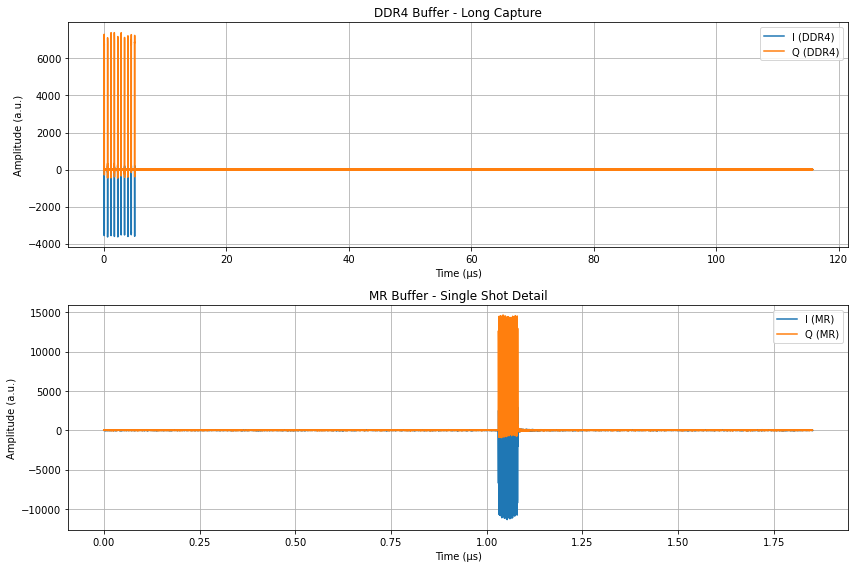

DDR4 captured 64000 samples
MR captured 8192 samples


In [5]:
class BothBuffersProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="test_pulse", 
                       style="const", 
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        # Enable both buffers
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'],
                    ddr4=True, mr=True)

# Arm both buffers
soc.arm_ddr4(ch=RO_CH, nt=10000)
soc.arm_mr(ch=RO_CH)

# Run 10 repetitions to fill buffers
prog = BothBuffersProgram(soccfg, reps=10, final_delay=0.5, cfg=config_mr)
iq_list = prog.acquire(soc, rounds=1)

# Read both buffers
iq_ddr4 = soc.get_ddr4(500)
iq_mr = soc.get_mr()

t_ddr4 = prog.get_time_axis_ddr4(RO_CH, iq_ddr4)
t_mr = prog.get_time_axis_mr(RO_CH, iq_mr)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t_ddr4, iq_ddr4[:,0], label='I (DDR4)')
axes[0].plot(t_ddr4, iq_ddr4[:,1], label='Q (DDR4)')
axes[0].set_xlabel('Time (µs)')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].set_title('DDR4 Buffer - Long Capture')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_mr, iq_mr[:,0], label='I (MR)')
axes[1].plot(t_mr, iq_mr[:,1], label='Q (MR)')
axes[1].set_xlabel('Time (µs)')
axes[1].set_ylabel('Amplitude (a.u.)')
axes[1].set_title('MR Buffer - Single Shot Detail')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"DDR4 captured {len(iq_ddr4)} samples")
print(f"MR captured {len(iq_mr)} samples")

## 6. Analyzing Buffer Data with FFT

You can perform frequency domain analysis on buffer data to examine signal spectra.

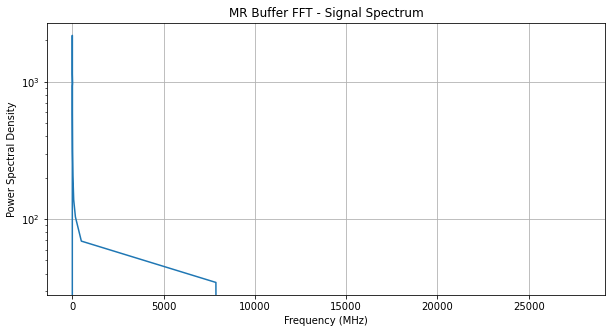

Peak frequency: 0.310 MHz
Expected frequency: 500 MHz (downconverted to DC)


In [8]:
from scipy.signal import welch
from numpy.fft import fftshift

# Get MR buffer data and compute power spectral density
iq_mr = soc.get_mr()
complex_signal = iq_mr.dot([1, 1j])

# Readout sample rate (depends on your firmware)
fs_mr = soccfg['readouts'][RO_CH]['fs']  # MHz

# Compute PSD using Welch's method
fft_freqs, psd = fftshift(welch(complex_signal, fs_mr, 
                                return_onesided=False, 
                                nperseg=128, 
                                detrend=False), axes=0)

plt.figure(figsize=(10, 5))
plt.semilogy(fft_freqs, psd)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power Spectral Density')
plt.title('MR Buffer FFT - Signal Spectrum')
plt.grid(True)
plt.show()

# Find the peak frequency
peak_idx = np.argmax(psd)
peak_freq = fft_freqs[peak_idx]
print(f"Peak frequency: {peak_freq:.3f} MHz")
print(f"Expected frequency: {config_mr['freq']} MHz (downconverted to DC)")

## 7. Buffer Management Tips

**Buffer Sizing:**
- DDR4: `nt` = number of transfers. Each transfer = 256 decimated samples
- MR: Fixed size (varies by firmware, typically 8192 samples)
- Both buffers are circular; old data is overwritten

**Estimating buffer needs:**
```python
# For a program with:
# - reps = N
# - sweep_steps = M
# - readout_length = L (samples)
# Total samples = N * M * L
# Transfers needed = ceil(total_samples / 256)
```

**Best practices:**
1. **Arm buffers before running the program** - They start capturing immediately
2. **Request extra samples when reading** - Use `get_ddr4(n)` with n larger than expected
3. **Use `get_time_axis_*` methods** - They compute the correct time axis for each buffer type
4. **Clear buffers between experiments** - Old data may persist

In [7]:
# Example: Clearing buffers between experiments
def clear_buffers(soc, ro_ch):
    """Clear DDR4 and MR buffers by re-arming them with 0 transfers."""
    soc.arm_ddr4(ch=ro_ch, nt=0)
    soc.arm_mr(ch=ro_ch)
    print("Buffers cleared")

# clear_buffers(soc, RO_CH)

## 8. Summary

You have learned:
- The difference between DDR4 and MR buffers
- How to capture data to the DDR4 buffer for long acquisitions
- How to capture data to the MR buffer for fast, tProc-accessible data
- How to use both buffers simultaneously
- How to perform frequency analysis on buffer data
- Best practices for buffer management

**When to use each buffer:**
- **DDR4:** Long acquisitions, many repetitions, post-processing analysis
- **MR:** Fast feedback, real-time decisions, single-shot analysis
- **Both:** When you need both long-term storage and real-time access

**Next steps:** Proceed to [`09_Appendix_Tips_And_Limits.ipynb`](./09_Appendix_Tips_And_Limits.ipynb) for a reference guide on common pitfalls, hardware limits, and debugging tips.